%md
# Avaliação Final do Modelo — Soja
Este notebook documenta o processo de avaliação do melhor modelo treinado para classificação de doenças em folhas de soja.

**Etapas cobertas:**

- Configuração do ambiente e importações
- Carregamento dos dados de teste
- Carregamento do modelo registrado no MLflow
- Avaliação com métricas e matriz de confusão
- Registro dos resultados no MLflow

## 1. Imports e configuração inicial

Nesta etapa carregamos as bibliotecas necessárias e ajustamos configurações globais para reprodutibilidade e organização do ambiente.

In [0]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [0]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import shutil
import tempfile
import base64
from datetime import datetime
from IPython.display import HTML, display

import mlflow
from mlflow.models.signature import infer_signature

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch

from src.dataset.soja_dataset import criar_dataloaders
from src.evaluate import evaluate_model

In [0]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = "/Volumes/workspace/agro-diasease/soja/dataset_soja_split/"

df_compare_spark = spark.table("workspace.`agro-diasease`.df_compare")
df_compare = df_compare_spark.toPandas()

best_run_id = df_compare.iloc[0]["run_id"]
best_run_name_model = df_compare.iloc[0]["model"]

print(best_run_name_model)
print(best_run_id)

resnet18
b2d796ffff814bf0b276248b94f37a5e


%md
## 2. Preparação do conjunto de teste

Aqui carregamos o DataLoader de teste e as classes do problema. Essa etapa garante que a avaliação seja realizada apenas em dados não vistos durante o treinamento.

In [0]:
_, _, test_loader = criar_dataloaders(batch_size=32, num_workers=0)

classes = test_loader.dataset.classes
num_classes = len(classes)

print("Classes:", classes)

Classes: ['Crestamento', 'Ferrugem', 'Mancha_Parda', 'Mosaico_Amarelo', 'Oidio', 'Podridao_Sul', 'Queima_Bacteriana', 'Septoriose', 'Sindrome_Morte_Subita', 'Soja_Saudavel', 'Virus_Mosaico']


## 3. Carregamento do melhor modelo
Com o best_run_id selecionado no notebook de treinamento, montamos a URI do artefato e carregamos o modelo salvo no MLflow.

In [0]:
model_uri = f"runs:/{best_run_id}/model"
model = mlflow.pytorch.load_model(model_uri)

model.to(device)
model.eval()

print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


## 4. Execução da avaliação
Executamos a função de avaliação para obter métricas de desempenho (como acurácia e F1) e a matriz de confusão.


In [0]:
result = evaluate_model(
    model,
    test_loader,
    device,
    class_names=classes
)

print("Test Accuracy:", result["accuracy"])
print(result["classification_report"])

Test Accuracy: 0.9954389965792474
                       precision    recall  f1-score   support

          Crestamento       1.00      1.00      1.00         1
             Ferrugem       1.00      0.73      0.84        11
         Mancha_Parda       1.00      1.00      1.00        13
      Mosaico_Amarelo       0.94      1.00      0.97        17
                Oidio       1.00      1.00      1.00        22
         Podridao_Sul       0.91      1.00      0.95        10
    Queima_Bacteriana       1.00      1.00      1.00        14
           Septoriose       0.67      1.00      0.80         4
Sindrome_Morte_Subita       1.00      1.00      1.00        17
        Soja_Saudavel       1.00      1.00      1.00       764
        Virus_Mosaico       1.00      0.75      0.86         4

             accuracy                           1.00       877
            macro avg       0.96      0.95      0.95       877
         weighted avg       1.00      1.00      1.00       877



## 5. Visualização da matriz de confusão
A matriz de confusão ajuda a identificar quais classes são mais confundidas entre si, apoiando análises de erro e melhorias futuras.

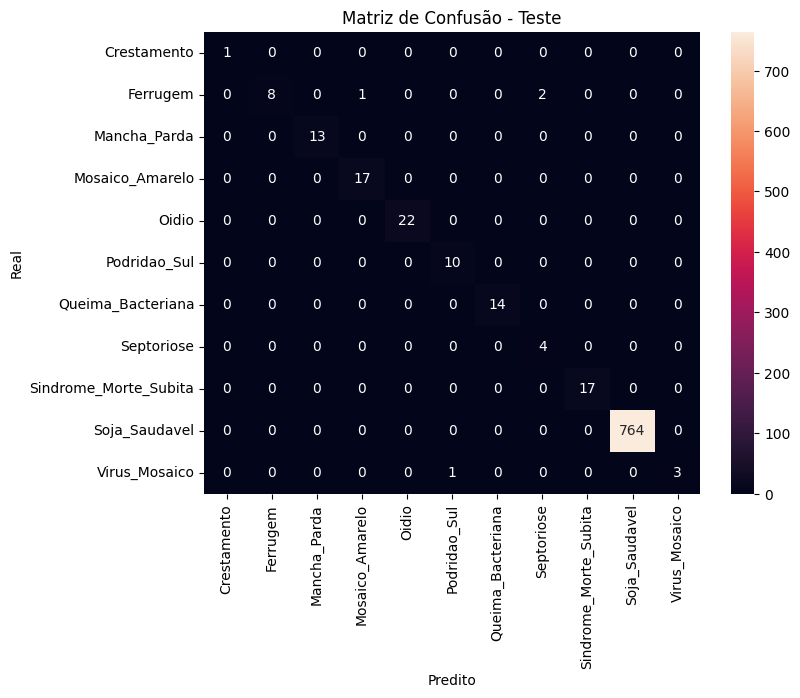

In [0]:
cm = result["confusion_matrix"]

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Teste")

plt.savefig("figures/confusion_matrix_test_soja.png")
plt.show()

## 6. Registro dos resultados no MLflow

Por fim, registramos métricas e artefatos no experimento de avaliação para manter a rastreabilidade dos resultados.

Itens logados:

- parâmetro evaluated_run_id (qual run foi avaliado);
- métrica test_accuracy;
- artefato da matriz de confusão (.png);
- artefato de relatório textual (classification_report.txt).

Com isso, a avaliação fica versionada e comparável dentro do histórico do MLflow.

In [0]:
mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="evaluation_best_model"):

    mlflow.log_param("evaluated_run_id", best_run_id)

    mlflow.log_metric("test_accuracy", result["accuracy"])

    mlflow.log_artifact("figures/confusion_matrix_test_soja.png")

    with open("classification_report.txt", "w") as f:
        f.write(result["classification_report"])

    mlflow.log_artifact("classification_report.txt")

    print("Avaliação logada no MLflow!")

Avaliação logada no MLflow!


## 7. Validação do modelo pyfunc carregado do MLflow

Aqui fazemos um teste funcional de ponta a ponta do modelo empacotado como mlflow.pyfunc:

- carregamos o modelo por `run_id` específico;
- extraímos uma amostra real do dataset de teste (image, label);
- chamamos `predict(...)` com batch unitário;
- comparamos a predição com o rótulo real e exibimos a confiança.

A saída esperada (mensagem de sucesso + predição/confiança/label real) confirma que o artefato está servível para integração.

In [0]:
test_model_uri = f"runs:/{best_run_id}/model"

loaded_pyfunc_model = mlflow.pyfunc.load_model(test_model_uri)

_, _, test_loader = criar_dataloaders(batch_size=32, num_workers=0)

classes = test_loader.dataset.classes

image, label = test_loader.dataset[1]

prediction = loaded_pyfunc_model.predict(
    image.unsqueeze(0).numpy()
)
label_real = classes[label]

predicted_class_idx = np.argmax(prediction[0])
predicted_class = classes[predicted_class_idx]
confidence = np.max(np.exp(prediction[0]) / np.sum(np.exp(prediction[0])))

print("\n✅ Teste de carregamento bem-sucedido!")
print(f"Predição: {predicted_class}")
print(f"Confiança: {confidence:.4f}")
print(f"Label real: {label_real}")


✅ Teste de carregamento bem-sucedido!
Predição: Ferrugem
Confiança: 0.9836
Label real: Ferrugem


## 8. Registro do modelo no Model Registry e criação de alias

Após validar a inferência, registramos o modelo no catálogo com nome estável `modelo_soja_doencas_pyfunc`.

Nesta célula:

- criamos uma nova versão no Registry;
- definimos o alias `@production` para essa versão;
- imprimimos o URI recomendado para uso em aplicações `models:/...@production`.

Esse passo desacopla a API de run_id fixo e facilita promoção de versões.

In [0]:
model_name = "modelo_soja_doencas_pyfunc"
model_uri = f"runs:/{best_run_id}/model"

print(f"Registrando modelo no Unity Catalog: {model_name}")

model_version = mlflow.register_model(
    model_uri=model_uri,
    name=model_name
)

print(f"\n✅ Modelo registrado como versão {model_version.version}")

client = mlflow.tracking.MlflowClient()
client.set_registered_model_alias(
    name=model_name,
    alias="production",
    version=model_version.version
)

print(f"✅ Alias '@production' definido para versão {model_version.version}")
print(f"\n📌 Para usar na API:")
print(f"   MODEL_URI = 'models:/{model_name}@production'")
print(f"   model = mlflow.pyfunc.load_model(MODEL_URI)")

Registrando modelo no Unity Catalog: modelo_soja_doencas_pyfunc


Successfully registered model 'workspace.default.modelo_soja_doencas_pyfunc'.
2026/05/18 22:22:37 WARNING mlflow.tracking._model_registry.fluent: Run with id b2d796ffff814bf0b276248b94f37a5e has no artifacts at artifact path 'model', registering model based on models:/m-4e9b3be99823478097a48a7a018e6650 instead


Uploading artifacts:   0%|          | 0/13 [00:00<?, ?it/s]

🔗 Created version '1' of model 'workspace.default.modelo_soja_doencas_pyfunc': https://dbc-9c92b906-eef5.cloud.databricks.com/explore/data/models/workspace/default/modelo_soja_doencas_pyfunc/version/1?o=1016405703992070



✅ Modelo registrado como versão 1
✅ Alias '@production' definido para versão 1

📌 Para usar na API:
   MODEL_URI = 'models:/modelo_soja_doencas_pyfunc@production'
   model = mlflow.pyfunc.load_model(MODEL_URI)
